In [1]:
# import needed python libraries

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import statistics


### Dataset

You will use a dataset collected in July 2019 with statistics from the traffic using a tool called
Tstat (http://tstat.polito.it/). Tstat is a passive traffic monitor that exports flow records, i.e., a
single entry for each TCP/UDP stream in the network. Each flow record is composed of a rich
set of statistics.
The basic objects that passive monitoring tools capture are the packets that are transmitted
on the monitored link. We can group packets in flows if they share key IP header
information. A common choice is to consider: \
**Flow = (Protocol, IP Source Address, Source Port, IP Destination Address, Destination Port)** \
Tstat automatically aggregates by flow the traffic (packets) captured.
Beside classical flow-level fields, such as IP addresses, port numbers, packet and byte-wise
counters, Tstat extracts the domain names, which we use to label the TCP flows. The final
dataset is composed of 125 features, 122 numerical described with an initial “_” in the
featurename, plus the client IP address, the time when this flow was generated and the
label. We removed the information about the server IP.
You can find more information regarding the features in the file readme.txt.
The data provided is already divided in 2 parts for training (https_training.csv) and test
(https_test.csv).

Start the dataset on python. Substitute to the appropriate path to the dataset in your system

In [2]:
df_test = pd.read_csv("C:\\Users\\loren\\OneDrive\\Desktop\\PoliTo\\machine Learning\\https_test.csv")
df_train = pd.read_csv("C:\\Users\\loren\\OneDrive\\Desktop\\PoliTo\\machine Learning\\https_training.csv")



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\loren\\OneDrive\\Desktop\\PoliTo\\machine Learning\\https_test.csv'

### Objective

Explore the dataset and learn about feature behavior at different levels. Use various data \
visualization techniques and statistical analysis \
Produce different visualizations and statistical analysis grouping the data at the flow level \
(rows of the dataset), at the IP level (clients) and domain name level (labels).



# Section 1
## 1.1: Distributions of features (EPDF or ECDF) per flow, domain name or IP


First we analyse amount of different categories for each stratification: Different client IPs and different Domains 

In [ ]:
#how many different IPs/domain name in the dataset
print(f"there are {len(df_train)} different flows")
print(f"there are {len(df_train.groupby('c_ip'))} different client IPs")
print(f"there are {len(df_train.groupby('label'))} different Domains")


there are 147863 different flows
there are 738 different client IPs
there are 26 different Domains


Concerning the meaning of each feature, it is possible to notice some that carry very interpretable information: <br>


#### the most relevant features to analyse on the client side  are:

<ul> 
<li>  throughput / data volume : 
_c_bytes_all, _c_bytes_uniq, _c_appdataB, _c_pkts_all, _c_pkts_data

<li>reliability : 
_c_pkts_retx, _c_bytes_retx, _c_pkts_dup, _c_pkts_unk, _c_pkts_fc

<li>congestion window : 
_c_cwin_ini, _c_cwin_min, _c_cwin_max

<li>RTT : 
_c_rtt_avg, _c_rtt_min, _c_rtt_max, _c_rtt_std

<li>timing : 
_c_first, _c_last, _c_first_ack, _c_last_handshakeT

<li>MSS : 
_c_mss, _c_mss_max, _c_mss_min 
<br>


##### Important Server-side features 

Use at domain level and flow level:

<li>traffic volume
_s_bytes_all, _s_appdataB, _s_pkts_all

<li>retransmissions
_s_pkts_retx, _s_bytes_retx

<li>reliability
_s_pkts_dup, _s_pkts_ooo, _s_pkts_reor

<li>RTT
_s_rtt_avg, _s_rtt_max, _s_rtt_min, _s_rtt_std

<li>congestion window
_s_cwin_ini, _s_cwin_min, _s_cwin_max

<li>MSS
_s_mss, _s_mss_min, _s_mss_max  
<br>

_durat (duration)



#### Plotting the EPDF without grouping

In this way, it is possible to analyse the general behaviour of the features. Groupping wouldn't be reasonable since, as seen before, there to many categories to group by for this visualisation type

_c_mss 90% of its data equal to each other
_c_pkts_dup 90% of its data equal to each other
_c_pkts_fc 90% of its data equal to each other
_c_pkts_ooo 90% of its data equal to each other
_c_pkts_reor 90% of its data equal to each other
_c_pkts_rto 90% of its data equal to each other
_c_pkts_unfs 90% of its data equal to each other
_c_pkts_unk 90% of its data equal to each other
_c_sack_opt 90% of its data equal to each other
_c_syn_cnt 90% of its data equal to each other
_c_syn_retx 90% of its data equal to each other
_c_win_0 90% of its data equal to each other
_s_f1323_opt 90% of its data equal to each other
_s_mss 90% of its data equal to each other
_s_pkts_dup 90% of its data equal to each other
_s_pkts_fc 90% of its data equal to each other
_s_pkts_fs 90% of its data equal to each other
_s_pkts_ooo 90% of its data equal to each other
_s_pkts_reor 90% of its data equal to each other
_s_pkts_unfs 90% of its data equal to each other
_s_pkts_unrto 90% of its data equal to each other
_s

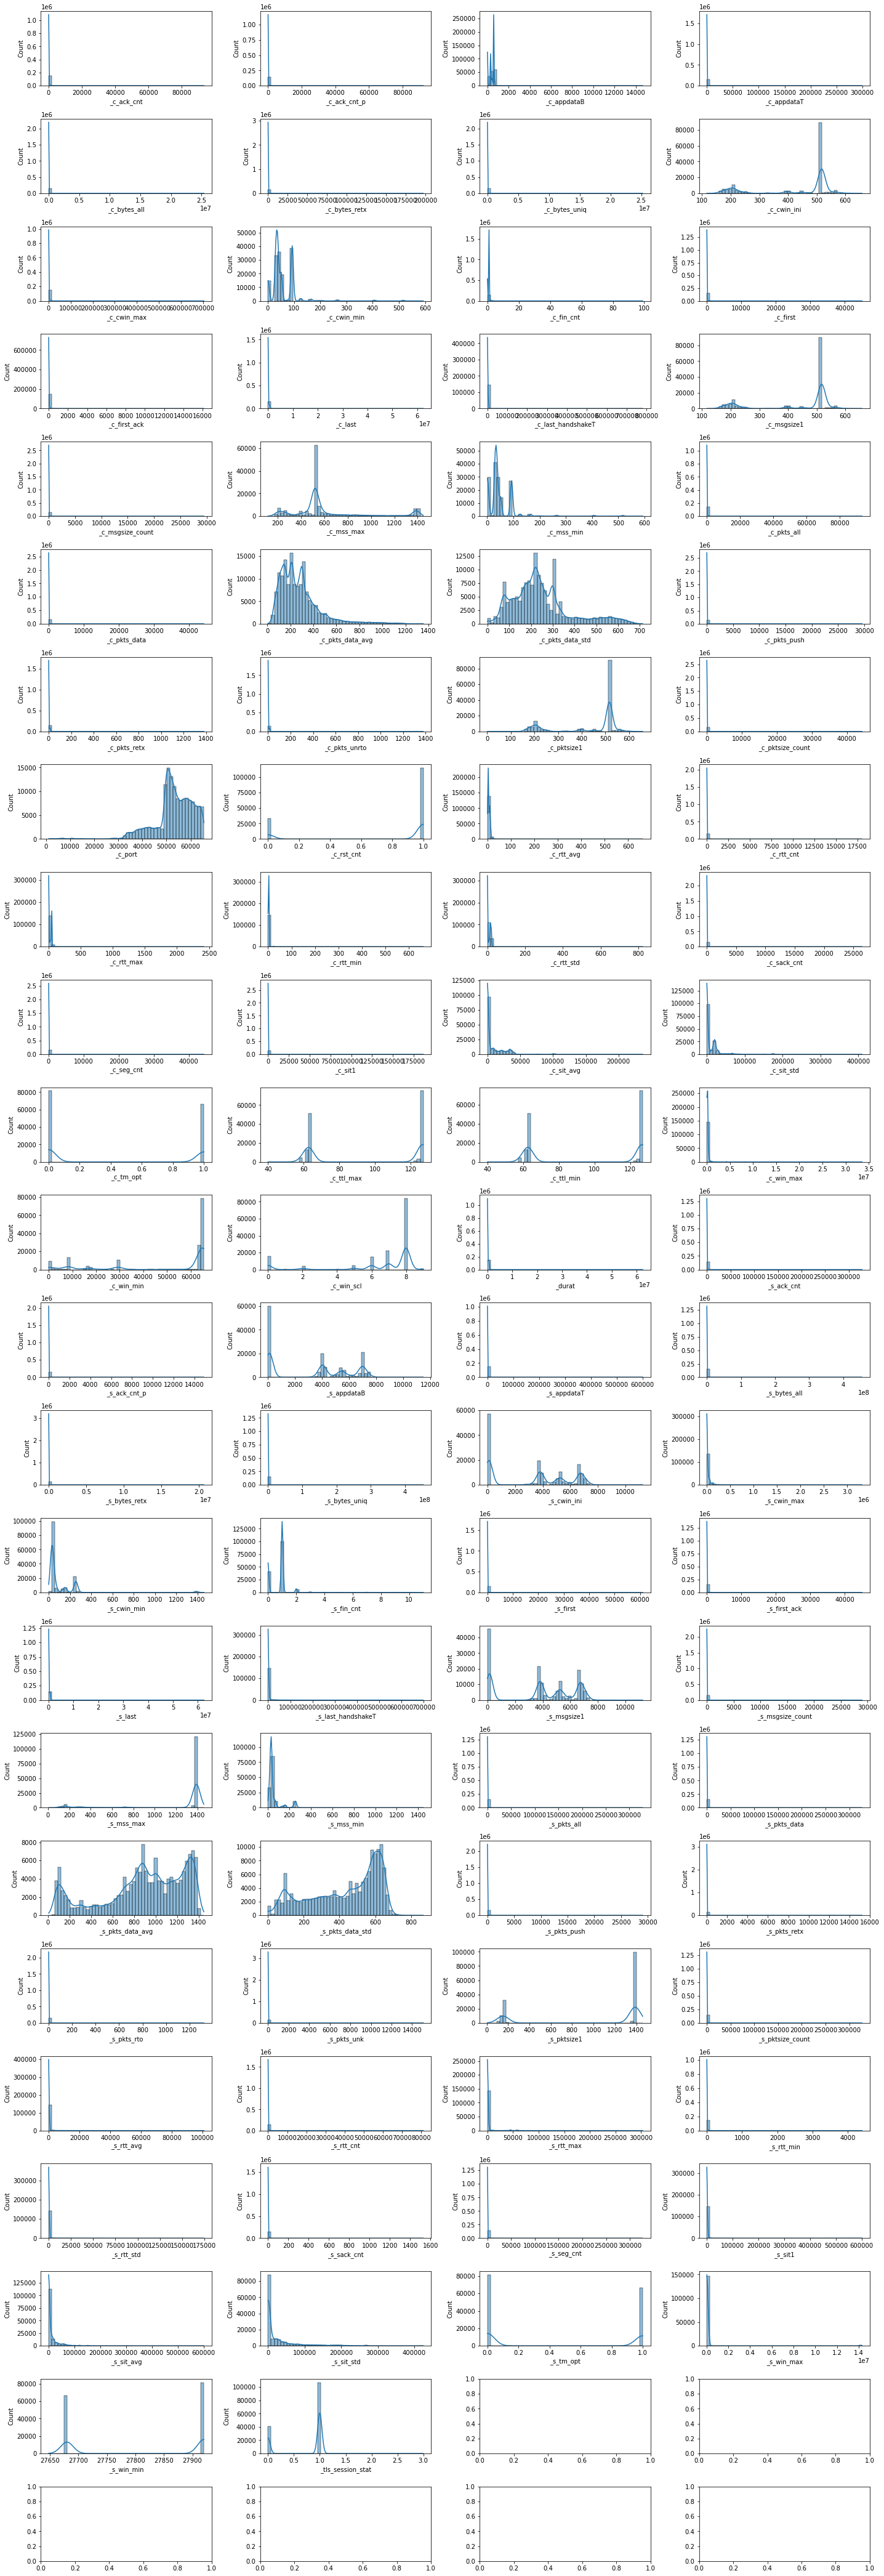

In [ ]:

fig, ax = plt.subplots(24, 4, figsize=(20, 60))
ax = ax.flatten()  

j = 0

for i in df_train.columns:
    if i.startswith("_"):
        if df_train[i].quantile(0.05) == df_train[i].quantile(0.95):
            print(i, "90% of its data equal to each other")
            continue

        # Plot ECDF for each class in "label"
        sns.histplot(
            data = df_train, 
            x = i, 
            ax = ax[j],
            kde = True,
            bins = 50
            #hue = "label", # check the distribution of different flower types
        )
        j+=1
        


print(j, "plots")

# Global legend (instead of per-subplot)
#handles, labels = first_ax.get_legend_handles_labels()
#ig.legend(handles, labels, loc='upper center', ncol=len(labels)/3, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

When trying to group by domain, it takes forever!!!


In [ ]:

#fig, ax = plt.subplots(24, 4, figsize=(20, 60))
#ax = ax.flatten()  
#
#j = 0
#
#for i in df_train.columns:
#    if i.startswith("_"):
#        if df_train[i].quantile(0.025) == df_train[i].quantile(0.975):
#            print(i, "95% of its data equal to each other")
#            continue
#
#        # Plot ECDF for each class in "label"
#        sns.histplot(
#            data = df_train, 
#            x = i, 
#            ax = ax[j],
#            hue = "label", # check the distribution of different flower types
#        )
#
#        j+=1
#        
#
#
#print(j, "plots")
#
## Global legend (instead of per-subplot)
##handles, labels = first_ax.get_legend_handles_labels()
##ig.legend(handles, labels, loc='upper center', ncol=len(labels)/3, fontsize=14)
#
#plt.tight_layout(rect=[0, 0, 1, 0.97])
#plt.show()

### Comments

In [ ]:
#plots that have very small bins have many unique values, in the case bellow, only a very faint line is visible at 0 (the mode)

print('_s_appdataT')
print('var: ', df_train['_s_appdataT'].var())
print('std: ', statistics.mode(df_train['_s_appdataT']))
print('unique values: ', len(df_train['_s_appdataT'].unique()))

#example of a plot that has few bins
print('unique values: ', len(df_train['_s_tm_opt'].unique()))

print('_s_rtt_avg')
print("var: ",df_train['_s_rtt_avg'].var())
print('mode: ',statistics.mode(df_train['_s_rtt_avg']))
print('unique values: ', len(df_train['_s_rtt_avg'].unique()))

#These graphs could be enhanced by beter automatic bin amount selection. but for now it is reasonable, since the plots bellow offer reasonable analysis 

_s_appdataT
var:  50893603.89748472
std:  0.0
unique values:  52961
unique values:  2
_s_rtt_avg
var:  9321737.245248979
mode:  0.0
unique values:  138011


### Plotting the ECDF for each domain

##### Custom ECDF plot function to avoid SNS limitations 

In [ ]:

def ecdf(ax, x, label=None, color=None):
    """Plot an ECDF on the given matplotlib axis."""
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where='post', label=label, color=color)



_c_pkts_fc 95% of its data equal to each other
_c_pkts_ooo 95% of its data equal to each other
_c_pkts_reor 95% of its data equal to each other
_c_pkts_rto 95% of its data equal to each other
_c_pkts_unfs 95% of its data equal to each other
_c_sack_opt 95% of its data equal to each other
_c_syn_cnt 95% of its data equal to each other
_c_syn_retx 95% of its data equal to each other
_c_win_0 95% of its data equal to each other
_s_mss 95% of its data equal to each other
_s_pkts_dup 95% of its data equal to each other
_s_pkts_fc 95% of its data equal to each other
_s_pkts_fs 95% of its data equal to each other
_s_pkts_ooo 95% of its data equal to each other
_s_pkts_reor 95% of its data equal to each other
_s_pkts_unfs 95% of its data equal to each other
_s_pkts_unrto 95% of its data equal to each other
_s_port 95% of its data equal to each other
_s_sack_opt 95% of its data equal to each other
_s_syn_cnt 95% of its data equal to each other
_s_syn_retx 95% of its data equal to each other
_s_

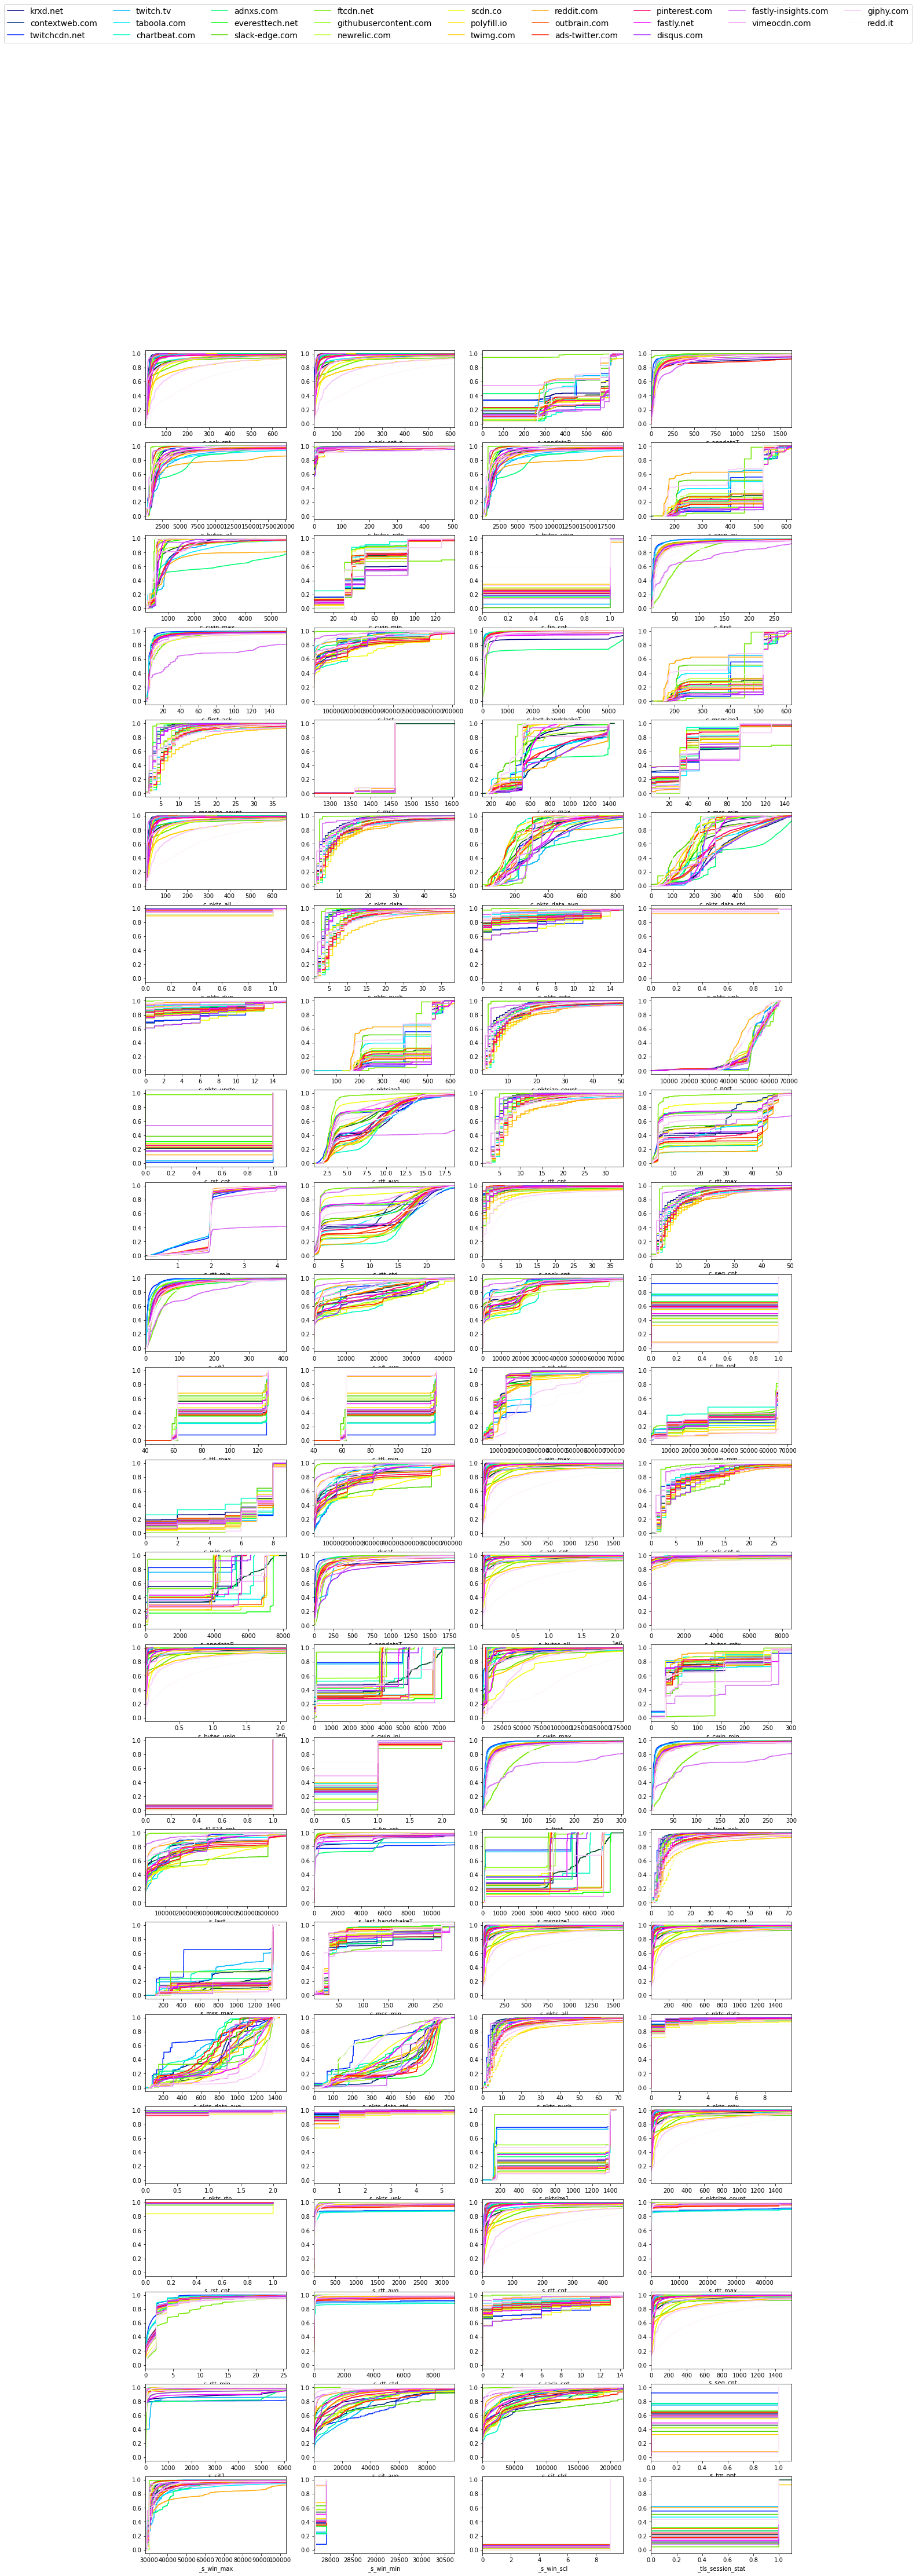

In [ ]:
fig, ax = plt.subplots(24, 4, figsize=(20, 70))
ax = ax.flatten()  

j = 0
first_ax = None

labels = df_train['label'].unique()
n_labels = len(labels)

# 25+ distinguishable colors
palette = plt.cm.gist_ncar(np.linspace(0, 1, n_labels))

# Map label → color
label_to_color = {lab: palette[k] for k, lab in enumerate(labels)}


for i in df_train.columns:
    if i.startswith("_"):
        if df_train[i].quantile(0.025) == df_train[i].quantile(0.975):
            print(i, "95% of its data equal to each other")
            continue

        # Plot ECDF for each class in "label"
        labels = df_train['label'].unique()
        for lab in labels:
            ecdf(ax[j], 
                 df_train.loc[df_train['label'] == lab, i].dropna().values,
                 label=str(lab),
                 color=label_to_color[lab]
                 )
        ax[j].set_xlabel(i)
        # Store first axis for global legend
        if first_ax is None:
            first_ax = ax[j]

        # x-limits
        low = df_train[i].min()
        high = df_train[i].quantile(0.975)
        ax[j].set_xlim(low, high * 1.1)

        j += 1

print(j, "plots")

# Global legend (instead of per-subplot)
handles, legend_labels = first_ax.get_legend_handles_labels()
if handles:
    ncols = max(1, (len(legend_labels) + 2) // 3)  # ceil(len/3)
    fig.legend(handles, legend_labels, loc='upper center', ncol=ncols, fontsize=14)




### Plotting the ECDF for  all the flows

_c_pkts_fc 95% of its data equal to each other
_c_pkts_ooo 95% of its data equal to each other
_c_pkts_reor 95% of its data equal to each other
_c_pkts_rto 95% of its data equal to each other
_c_pkts_unfs 95% of its data equal to each other
_c_sack_opt 95% of its data equal to each other
_c_syn_cnt 95% of its data equal to each other
_c_syn_retx 95% of its data equal to each other
_c_win_0 95% of its data equal to each other
_s_mss 95% of its data equal to each other
_s_pkts_dup 95% of its data equal to each other
_s_pkts_fc 95% of its data equal to each other
_s_pkts_fs 95% of its data equal to each other
_s_pkts_ooo 95% of its data equal to each other
_s_pkts_reor 95% of its data equal to each other
_s_pkts_unfs 95% of its data equal to each other
_s_pkts_unrto 95% of its data equal to each other
_s_port 95% of its data equal to each other
_s_sack_opt 95% of its data equal to each other
_s_syn_cnt 95% of its data equal to each other
_s_syn_retx 95% of its data equal to each other
_s_

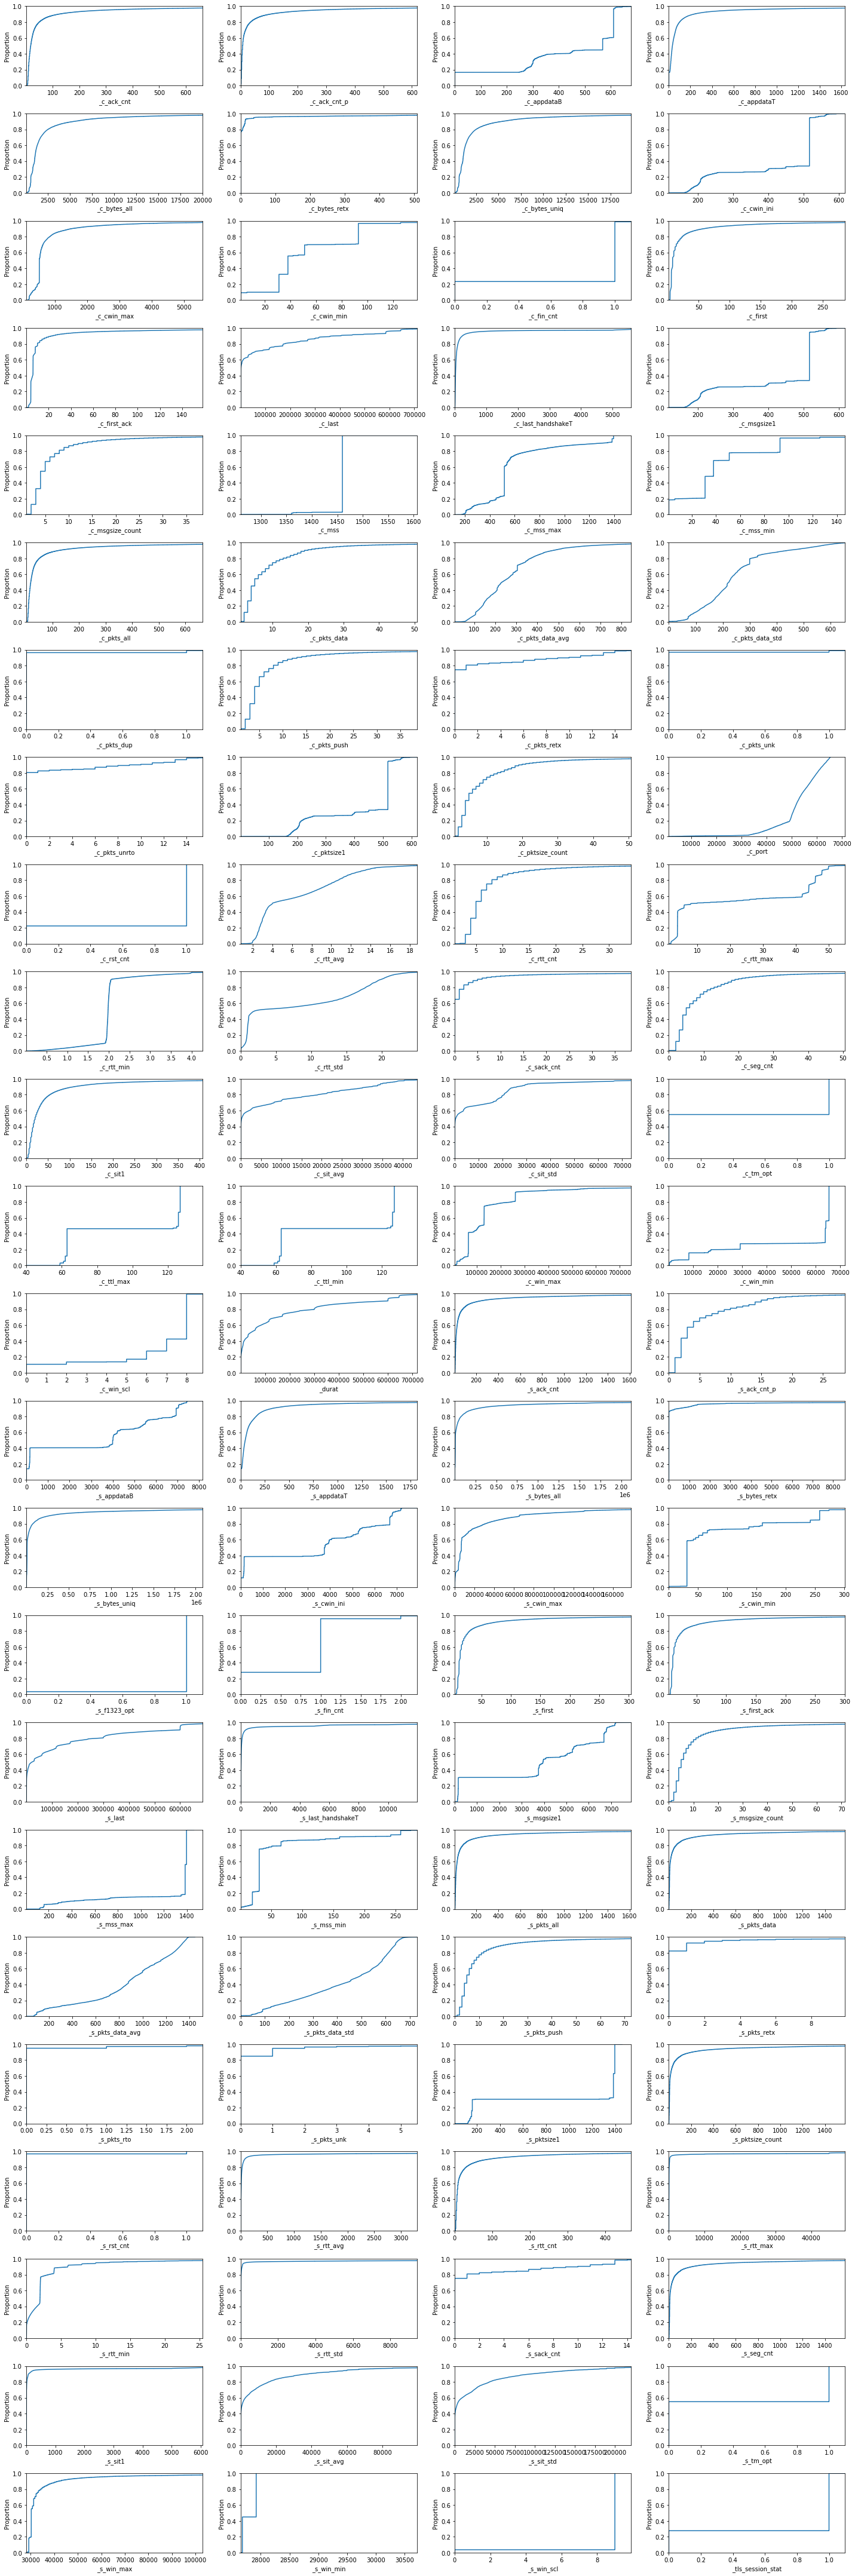

In [ ]:
fig, ax = plt.subplots(24, 4, figsize=(20, 60))
ax = ax.flatten()  

j = 0
first_ax = None

for i in df_train.columns:
    if i.startswith("_"):
        if df_train[i].quantile(0.025) == df_train[i].quantile(0.975):
            print(i, "95% of its data equal to each other")
            continue

        # Plot ECDF for each class in "label"
        sns.ecdfplot(data = df_train,
                     x = df_train[i],
                     ax = ax[j])


        # x-limits
        low = df_train[i].min()
        high = df_train[i].quantile(0.975)
        ax[j].set_xlim(low, high * 1.1)

        j += 1

print(j, "plots")


plt.tight_layout()
plt.show()

## 1.2 
### Statiscs for domain and IP groupped
 

I am merging the numerical features in :["mean", "median", "std", "min", "max"] \
since analysing feature per feature would be too much to handle <br>


#### the most relevant features to analyse on the client side  are:

use at client IP level
<ul> 
<li>  throughput / data volume : <br>
_c_bytes_all, _c_bytes_uniq, _c_appdataB, _c_pkts_all, _c_pkts_data

<li>reliability : <br>
_c_pkts_retx, _c_bytes_retx, _c_pkts_dup, _c_pkts_unk, _c_pkts_fc

<li>congestion window : <br>
_c_cwin_ini, _c_cwin_min, _c_cwin_max

<li>RTT : <br>
_c_rtt_avg, _c_rtt_min, _c_rtt_max, _c_rtt_std

<li>timing : <br>
_c_first, _c_last, _c_first_ack, _c_last_handshakeT

<li>MSS : <br>
_c_mss, _c_mss_max, _c_mss_min 
<br>


##### Important Server-side features 

Use at domain level 

<li>traffic volume<br>
_s_bytes_all, _s_appdataB, _s_pkts_all

<li>retransmissions<br>
_s_pkts_retx, _s_bytes_retx

<li>reliability<br>
_s_pkts_dup, _s_pkts_ooo, _s_pkts_reor

<li>RTT<br>
_s_rtt_avg, _s_rtt_max, _s_rtt_min, _s_rtt_std

<li>congestion window<br>
_s_cwin_ini, _s_cwin_min, _s_cwin_max

<li>MSS <br>
_s_mss, _s_mss_min, _s_mss_max  
<br>

_durat (duration)
<br>
We select a subset of these to analyse, since they are too many and some are redundant




In [ ]:
def get_distinct(x):
    return(len(set(x)))

def get_mode(x):
    return x.mode()

num_features = [col for col in df_train.columns if col.startswith("_")]

c_feats = {
    # Traffic volume
    "_c_bytes_all": ['max',np.average],         #Analyse Total network occupancy required by a client           -> max, avg
    "_c_bytes_retx": ['max',np.average],        #analyse the retransmission to look at overflow seen by clients -> max, avg
    "_c_pkts_all": ['max',np.average],          #Analyse the total amount pkts, probably correlated to bytes all-> max, avg

    # Reliability / packet anomalies
    "_c_pkts_retx": ['max',np.average],         #Analyse retransmitted packets                                  -> max, avg
    "_c_pkts_unk": [np.average],          #Pkts which are not in sequence unclassified dup                ->avg

    # Congestion window
    "_c_cwin_max": ['max',np.average],          #                                                               ->max 

    # RTT statistics
    "_c_rtt_avg": ['max',np.average],           #                                                               ->avg
    "_c_rtt_max": ['max',np.average],           #                                                               ->avg, max     
    "_c_rtt_std": ['max', np.average],          #Standard deviation of the RTT for packets sent by the server. it gives an estimate on the jitter

    # Timing
    "_c_first": ['min'],             #see the first time it was contacted overall                    ->min
    "_c_last": ['max'],              #see the first time it was contacted overall                    ->max
    # MSS / segment size
    "_c_mss": [['max', np.average]],               # max segmantation size                                 ->max
    "_c_seg_cnt": [np.average],                     # Number of segments sent by the client.

    "_c_port": [get_distinct, 'size'],                         # Port number used by the client. NOTE also get how many samples where aggegated
    "_tls_session_stat": [statistics.mode, get_distinct],       #find how many different TLS modes and the most commo 
    "_durat": ['max', np.average]
}

s_feats = {
    # Traffic volume
    "_s_bytes_all": ['max',np.average],     #
    "_s_bytes_retx": ['max',np.average],    #
    "_s_pkts_all": ['max',np.average],      #

    # Reliability / anomalies
    "_s_pkts_retx": ['max',np.average],     #
    "_s_pkts_unk": ['max',np.average],      #

    # Congestion window

    "_s_cwin_max": ['max',np.average],      #

    # RTT statistics
    "_s_rtt_avg": ['max',np.average],       #
    "_s_rtt_max": ['max',np.average],       #
    "_s_rtt_std": ['max', np.average],       #Standard deviation of the RTT for packets sent by the server. it gives an estimate on the jitter


    # Timing
    "_s_first": ['min'],         #
    "_s_last": ['max'],          #


    
    "_s_port": [get_distinct, 'size'],                         # Port number used by the client. NOTE also get how many samples where aggegated
    "_tls_session_stat": [statistics.mode, get_distinct],          #find how many different TLS modes and the most common
    "_durat": ['max', np.average],                           #Duration of the connections.
}


#Min, Max, Avg, Std
df_ip = df_train.groupby("c_ip").agg(
    c_feats
)

df_dom = df_train.groupby("label").agg(
    s_feats
)

print(df_dom['_s_port']["size"])


label
_other                   35083
adnxs.com                 3839
ads-twitter.com           1325
chartbeat.com             1413
contextweb.com            2824
disqus.com                3173
everesttech.net           3408
fastly-insights.com       1309
fastly.net                1869
ftcdn.net                 3455
giphy.com                 3886
githubusercontent.com     4271
krxd.net                 11144
newrelic.com              2182
outbrain.com              5637
pinterest.com             1967
polyfill.io               1270
redd.it                   3085
reddit.com                3457
scdn.co                  25322
slack-edge.com            1064
taboola.com              21018
twimg.com                 1024
twitch.tv                 2383
twitchcdn.net             1436
vimeocdn.com              1019
Name: size, dtype: int64


## 1.3

### Find most correlated features (at the 3 levels)

The idea is to follow as done in lab 5:

<ol>
    <li> Scale the data 
    <li> Draw the Corr matrix 
    <li> Explain that highly correlated feats can be suppressed from the analysis 
<ol>


#### At flow level

We start by creating a copy with only the numerical values

In [ ]:
df_trainC = df_train.copy()
for i in df_trainC.columns: #reromve non numeric columns
    if not(i.startswith('_')):
        df_trainC = df_trainC.drop(i, axis=1) 

df_testC = df_test.copy()

for i in df_testC.columns: #reromve non numeric columns
    if not(i.startswith('_')):
        df_testC = df_testC.drop(i, axis=1) 



In [ ]:
def df_scaling(df_trainC):
    # define the scaler
    scaler = StandardScaler()

    # for each column in the dataset, fit and transform the data
    for col in df_trainC.columns:
        
        # fit the scaler on the data 
        scaler.fit(df_trainC[col].values.reshape(-1, 1))

        # transform the data
        df_trainC[col] = scaler.transform(df_trainC[col].values.reshape(-1, 1))

In [ ]:
# make a copy of the original dataset

df_scaling(df_trainC)
df_scaling(df_testC)



In [ ]:
def plot_corrMat(correlation_matrix, corr_lim=None):
    #if corr_lim passed, plot only correlations above limit
    
    if corr_lim:  
        filtered = correlation_matrix[correlation_matrix>corr_lim]
        columns_filtered = list(filtered.index)

        for i in filtered:
            if (filtered[i].values[np.logical_not(np.isnan(filtered[i].values))] == [1]).all():
                columns_filtered.remove(i)

        _ = len(columns_filtered)

        # Compute the heatmap
        plt.figure(figsize=(20,20))
        sns.heatmap(correlation_matrix.loc[columns_filtered, columns_filtered], cmap='Blues', vmin=.0, vmax=1, cbar_kws={'label':'Correlation'})
        plt.xlabel('Feature')
        plt.ylabel('Feature')
        plt.title(f'{_} highly correlated')
        plt.show()
        
        
    else: 
        plt.figure(figsize=(24,24))
        sns.heatmap(correlation_matrix, cmap='Blues', vmin=0.8, vmax=1, cbar_kws={'label':'Correlation'})
        plt.tight_layout()
        plt.show()
    


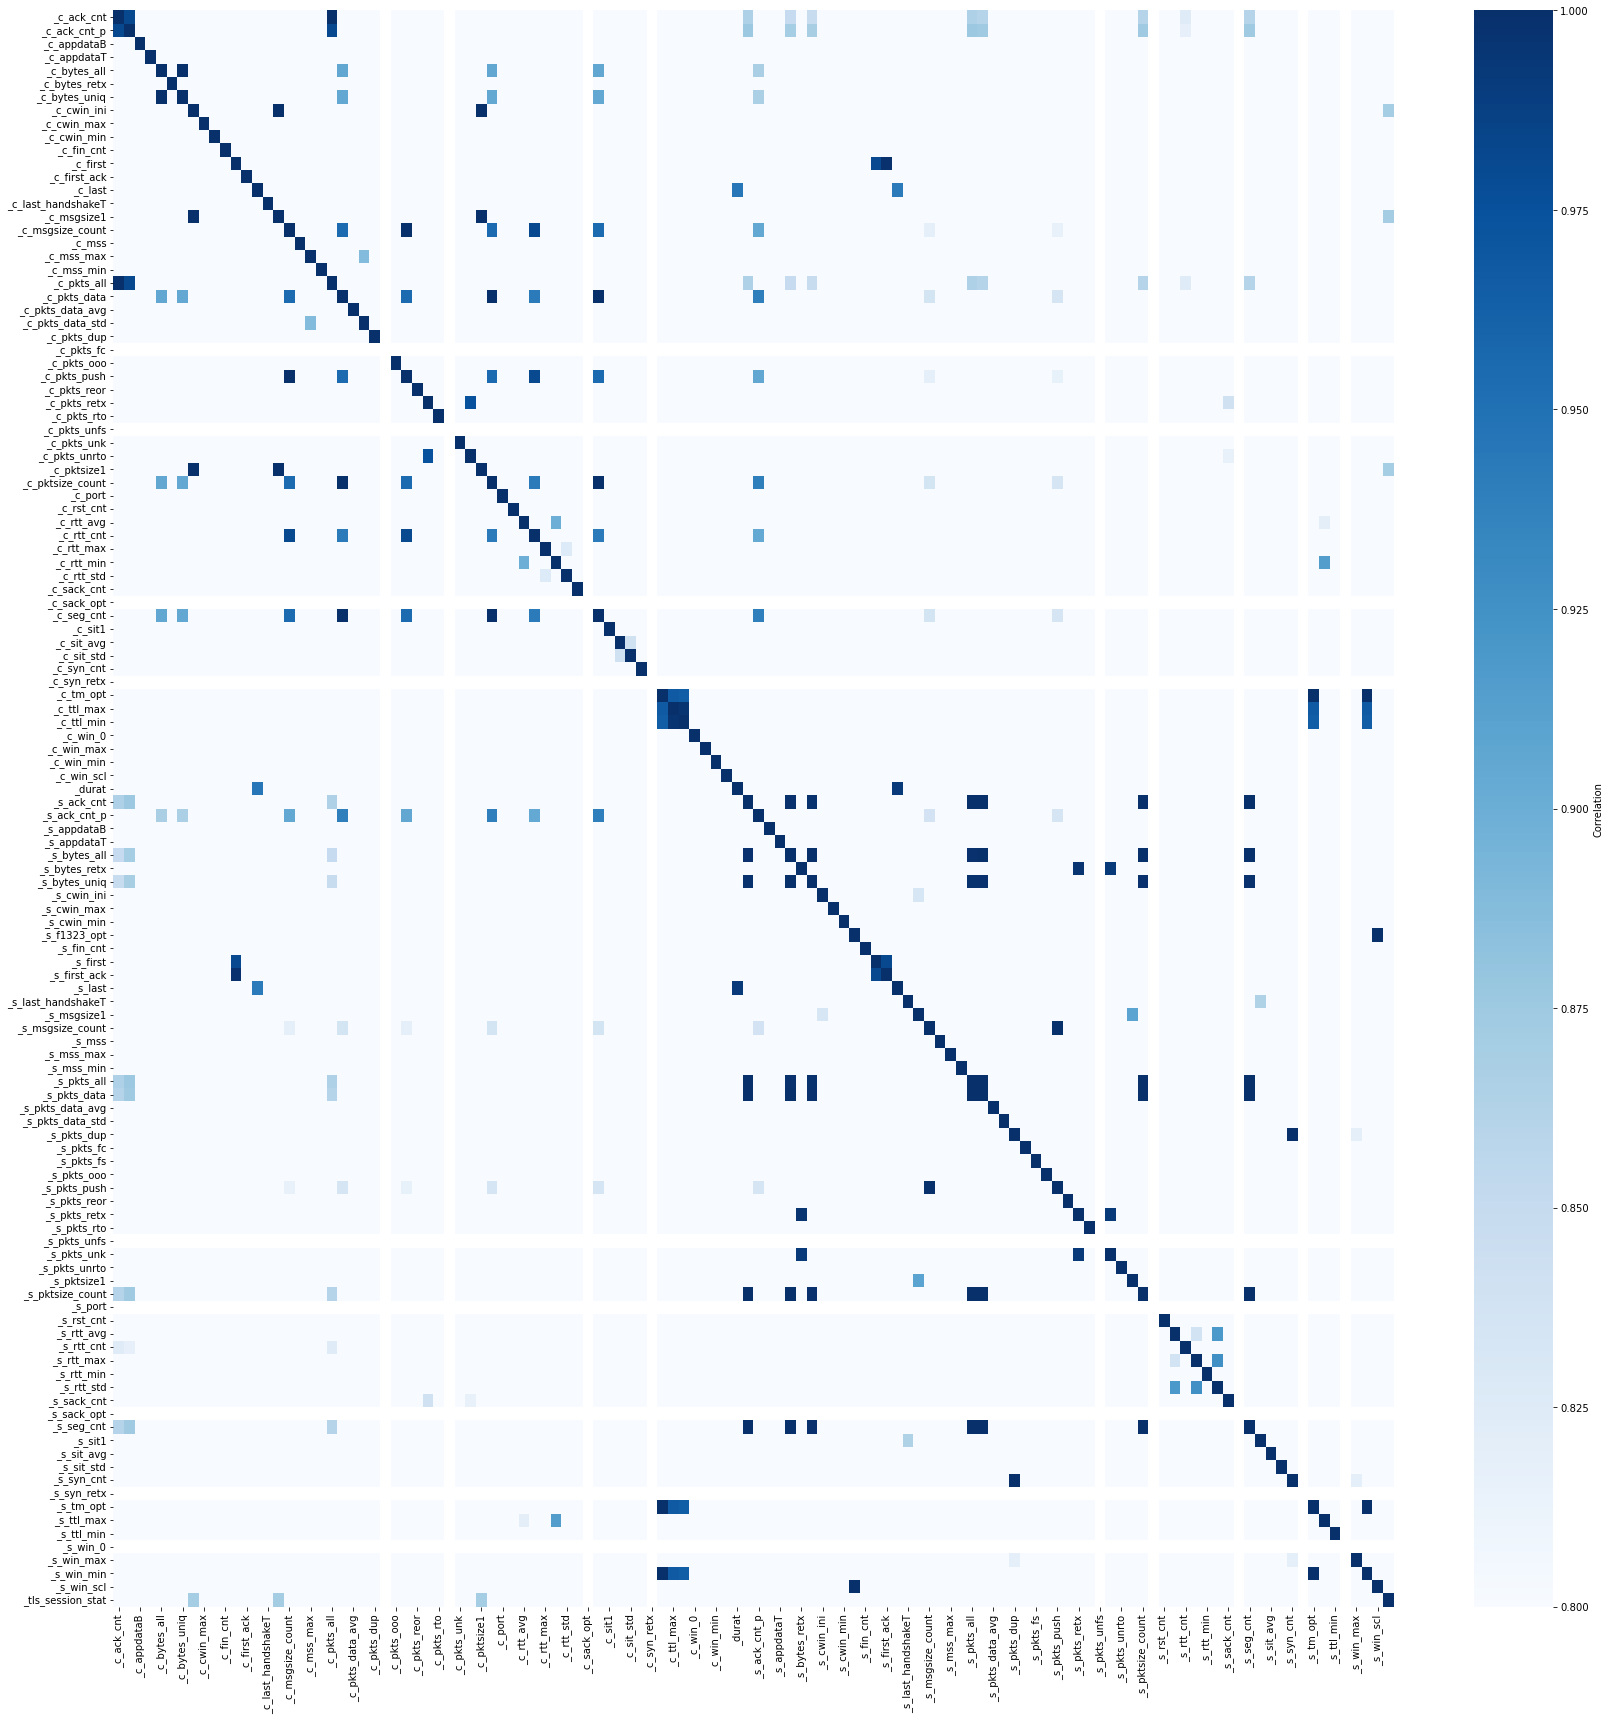

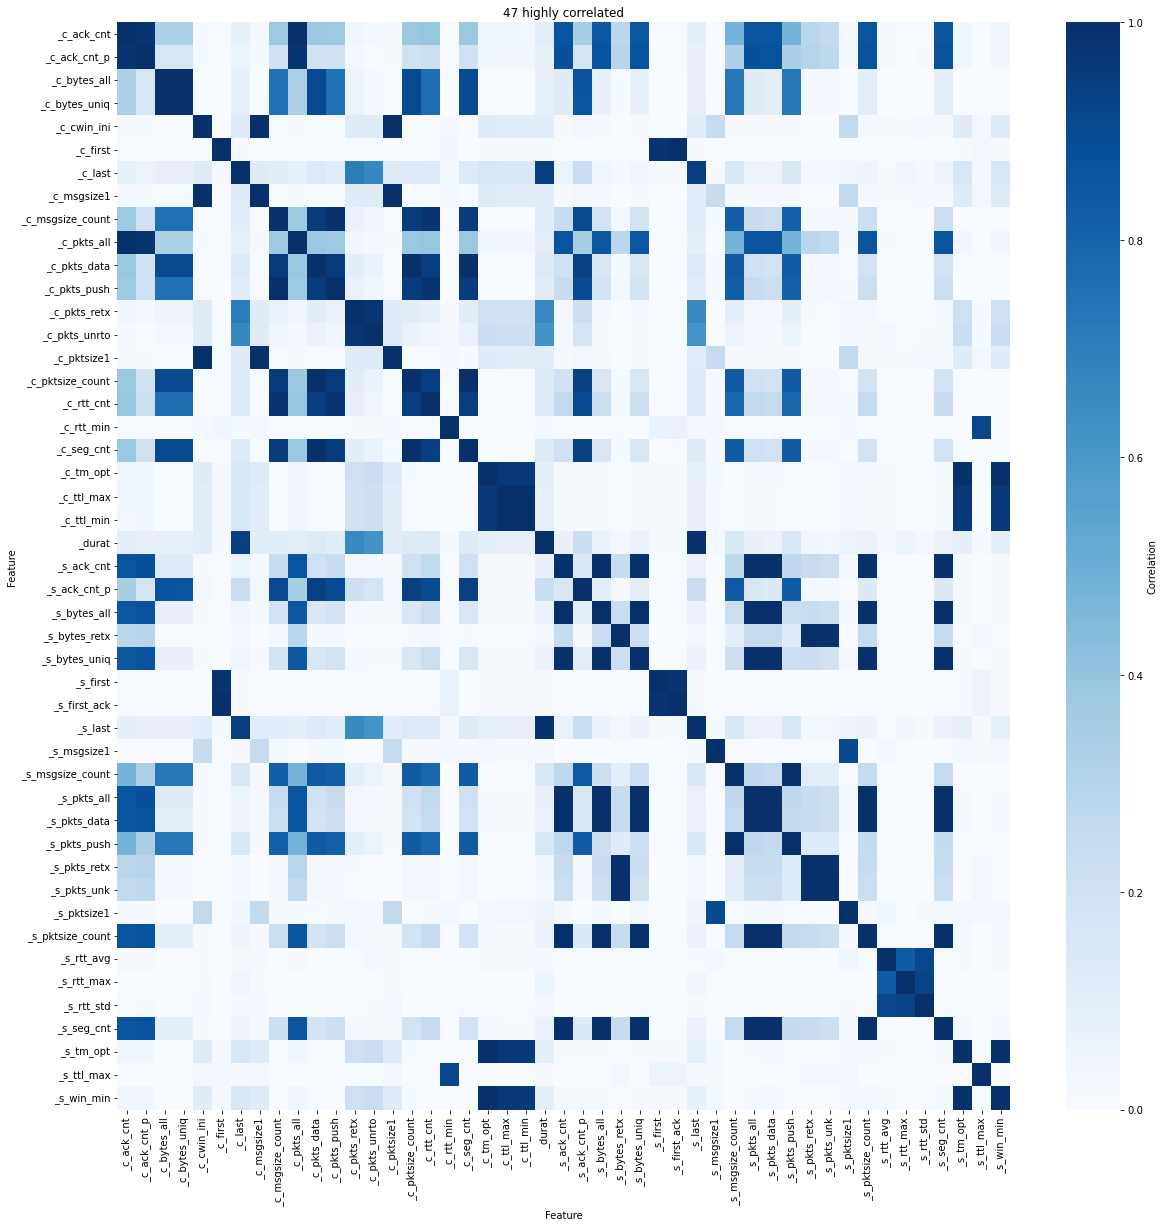

In [ ]:

correlation_matrix = df_trainC.corr().abs()

plot_corrMat(correlation_matrix)
plot_corrMat(correlation_matrix, corr_lim = 0.9)



### At ip level


In [ ]:
df_ipC = df_ip.copy()

df_scaling(df_ipC)


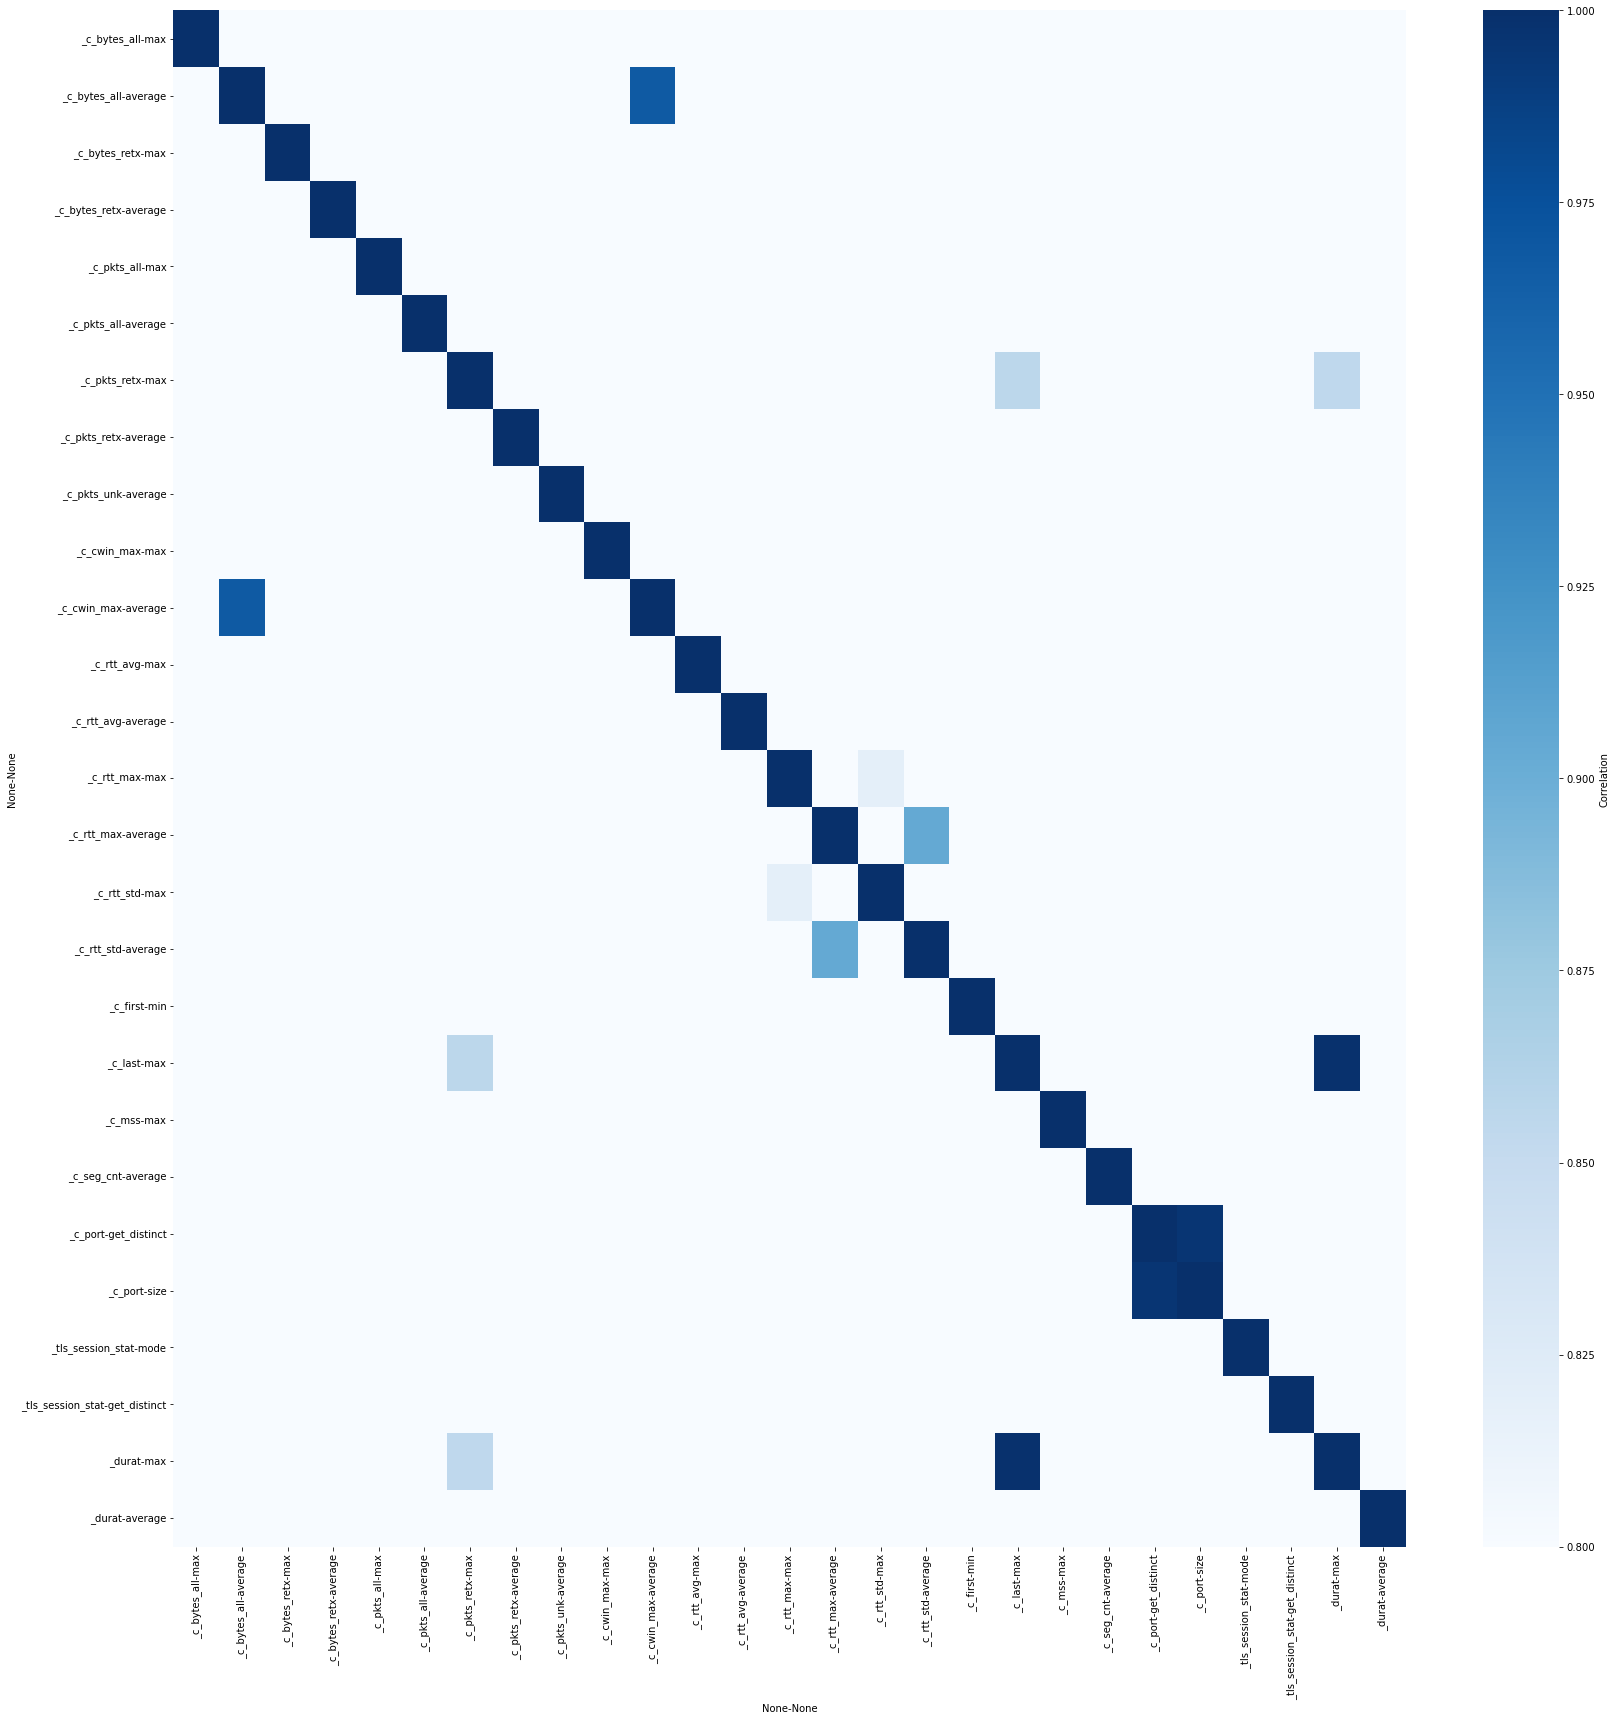

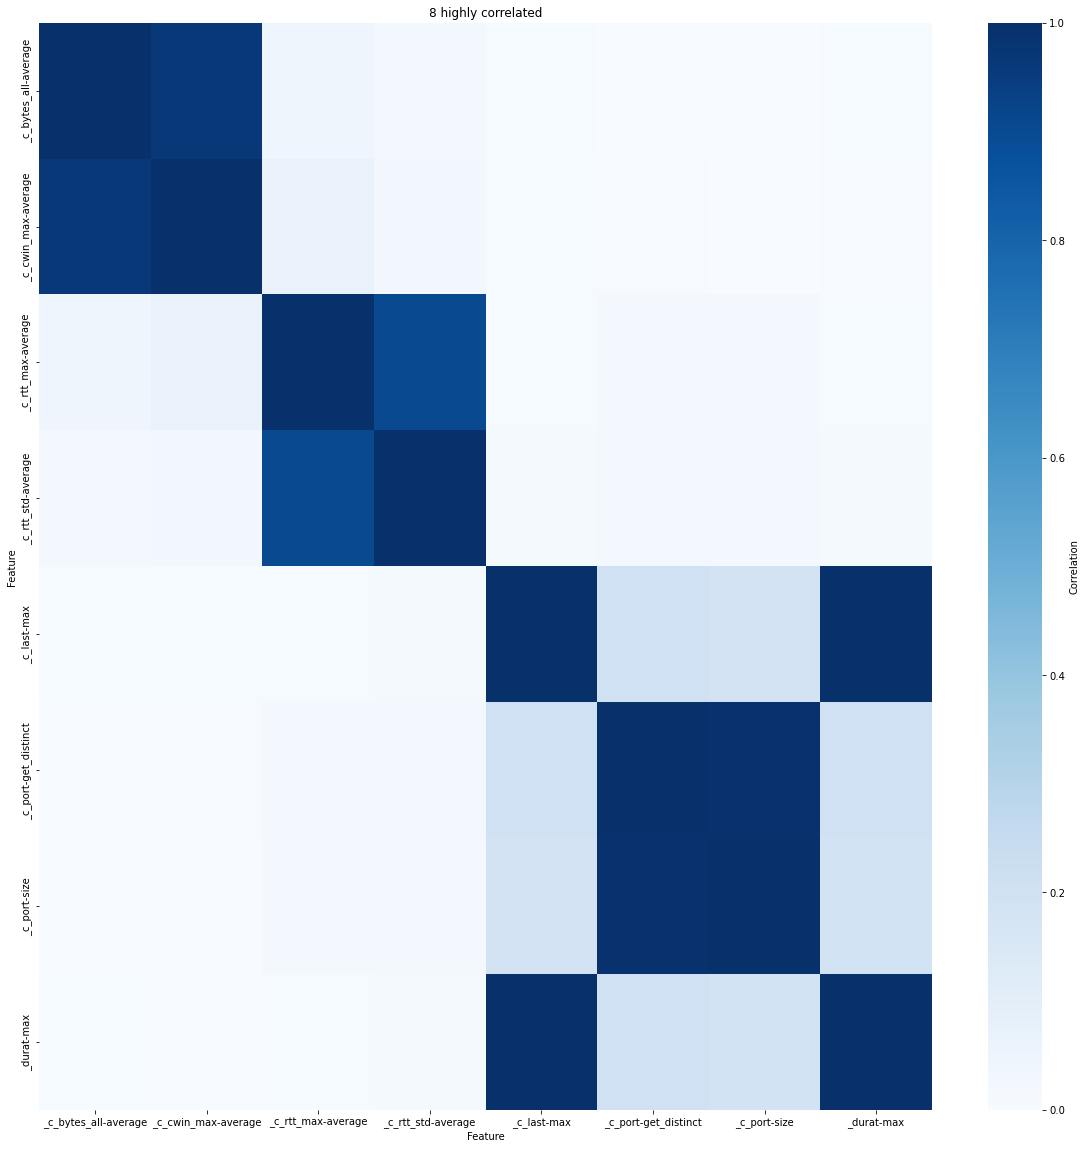

In [ ]:
correlation_matrix_ip = df_ipC.corr().abs()

plot_corrMat(correlation_matrix_ip)
plot_corrMat(correlation_matrix_ip, corr_lim = 0.9)


#### On domain  Level

In [ ]:
df_domC = df_dom.copy()

df_scaling(df_domC)

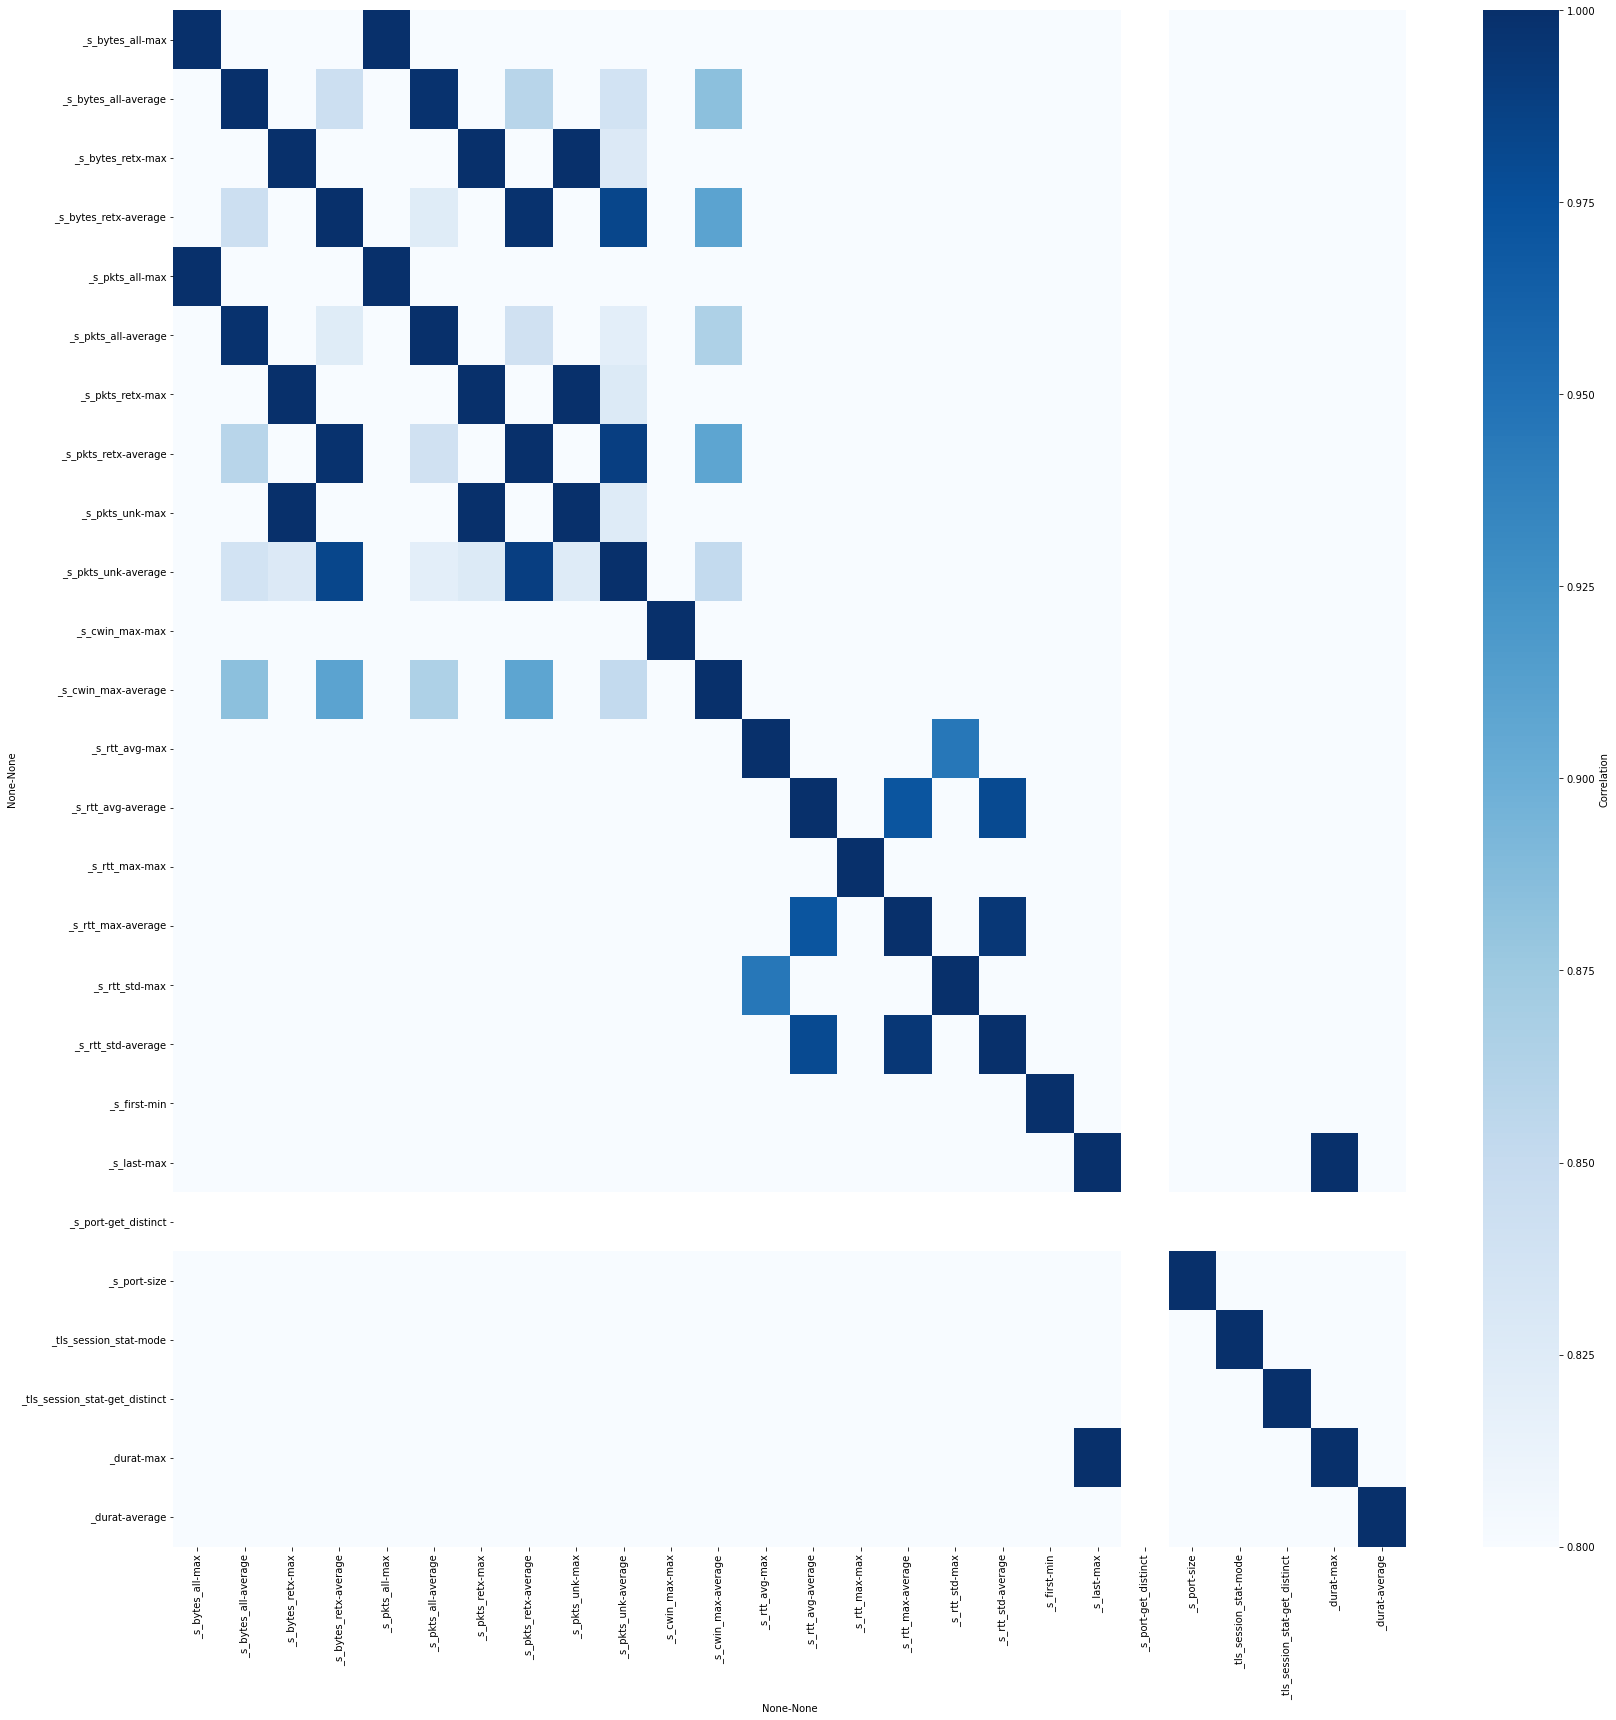

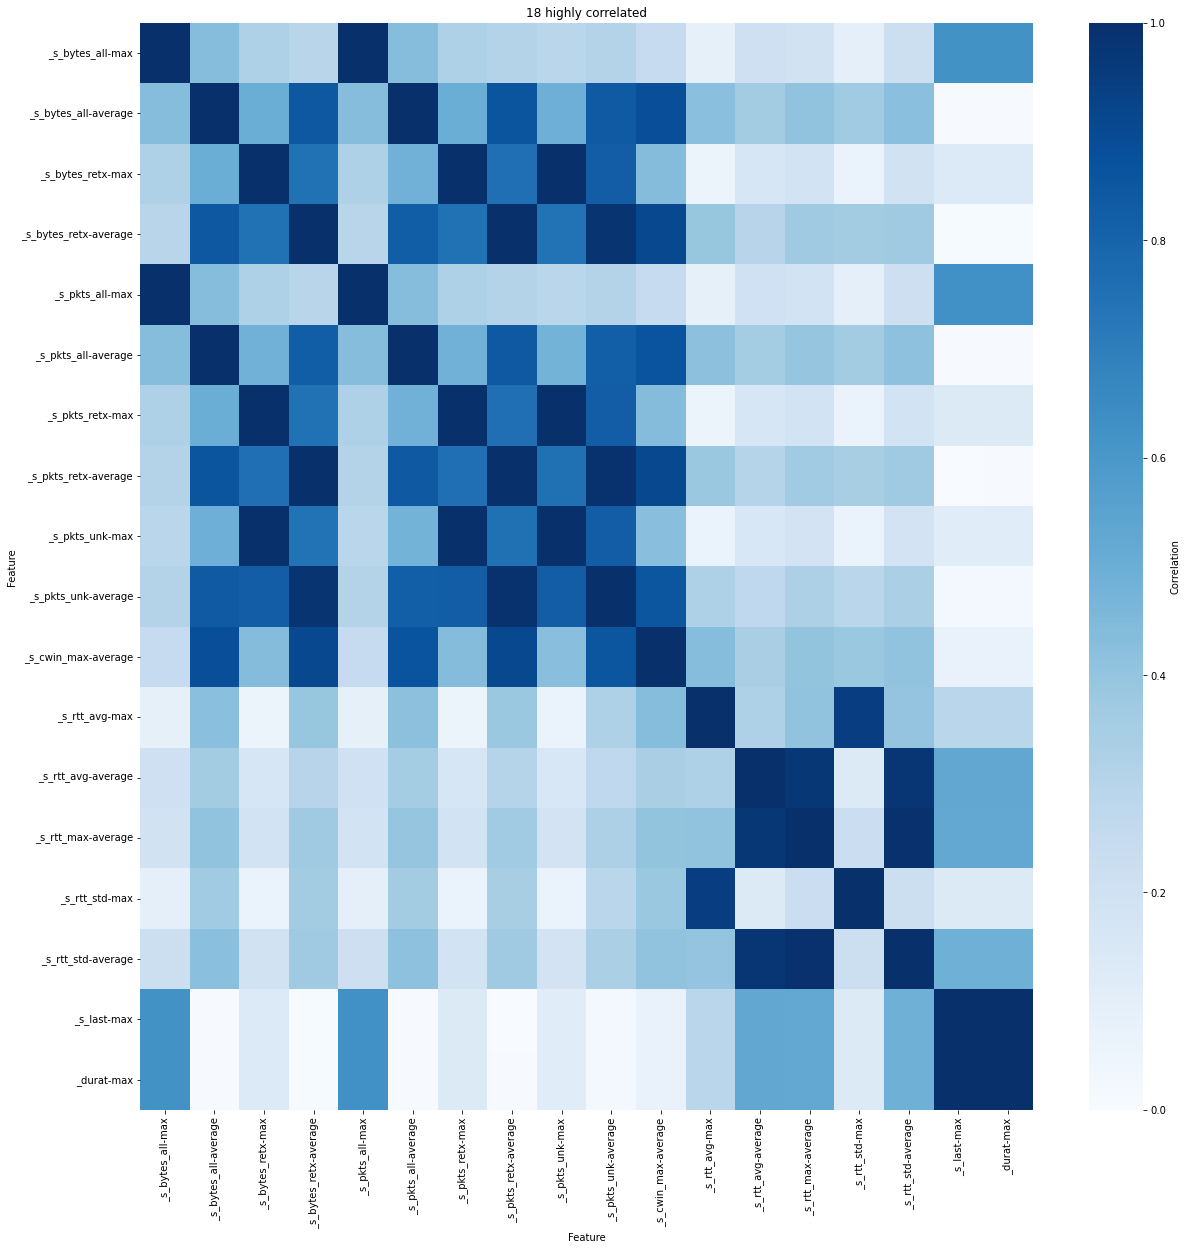

In [ ]:
columns= [i for i in range(df_domC.shape[1])]
correlation_matrix_dom = df_domC.corr().abs()

plot_corrMat(correlation_matrix_dom)
plot_corrMat(correlation_matrix_dom, corr_lim = 0.9)

## 1.4
### Statistics on number of bytes transmitted and RTT

In [ ]:
def print_describe_side_by_side(*dataframes, names=None, title=None):
    """
    Imprime estatísticas describe() lado a lado
    
    Parameters:
    *dataframes: DataFrames a serem comparados
    names: lista de nomes para cada DataFrame
    """
    
    stats = [df.describe() for df in dataframes]

    stats_prefixed = []
    
    print( type(stats[1]))
    combined = pd.DataFrame({name:stat for name, stat in zip(names, stats)})
    
    

    # Formata a saída
    pd.set_option('display.width', 200)
    pd.set_option('display.max_columns', None)
    
    print("\n" + "="*80)
    print("Statistics - ", title if title else "")
    print("="*80)
    print(combined.to_string())
    print("="*80)
    
    return
    



In [ ]:
#per flow

# Exemplo de uso
print_describe_side_by_side(df_train['_c_bytes_all'], df_ip['_c_bytes_all']['average'], df_dom['_s_bytes_all']['average'], 
                            names=['Flow', 'Average per IP', 'Average per Domain'],
                            title = 'Bytes all')

print("\nOf which, on average,", df_train['_c_bytes_retx'].mean(), "are from retransmissions \n")

print_describe_side_by_side(df_train['_c_rtt_avg'], df_ip['_c_rtt_avg']['average'], df_dom['_s_rtt_avg']['average'], 
                            names=['Flow', 'Average per IP', 'Average per Domain'],
                            title = 'RTT Average')


print_describe_side_by_side(df_train['_c_rtt_std'], df_ip['_c_rtt_std']['average'], df_dom['_s_rtt_std']['average'], 
                            names=['Flow', 'Average per IP', 'Average per Domain'],
                            title = 'RTT standard deviation')


<class 'pandas.core.series.Series'>

Statistics -  Bytes all
               Flow  Average per IP  Average per Domain
count  1.478630e+05    7.380000e+02        2.600000e+01
mean   5.112462e+03    5.601534e+03        2.303112e+05
std    1.403877e+05    4.715161e+04        3.292546e+05
min    1.170000e+02    1.850000e+02        4.470772e+03
25%    7.680000e+02    1.265239e+03        1.042230e+04
50%    1.142000e+03    2.082758e+03        5.353737e+04
75%    2.068000e+03    3.642052e+03        3.784693e+05
max    2.539156e+07    1.267905e+06        1.072831e+06

Of which, on average, 43.53751783745765 are from retransmissions 

<class 'pandas.core.series.Series'>

Statistics -  RTT Average
                Flow  Average per IP  Average per Domain
count  147863.000000      738.000000           26.000000
mean        7.093867        7.400437          663.980293
std        12.768000        3.985779          849.697342
min         0.780184        2.119447           27.189339
25%         2.84874

## 1.5

### Describe and motivate any further pre-processing employed on the data

When working at the flow level, i will work with the dataset without the highly correlated features


In [ ]:
import numpy as np
import pandas as pd

def remove_correlated_features(X_train, X_test, correlation_threshold=0.8):

    # Compute correlation matrix from training data
    corr = X_train.corr().abs()

    # Get upper triangle mask (pairwise correlations only once)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Find columns to drop
    to_be_deleted = [
        column for column in upper.columns
        if any(upper[column] > correlation_threshold)
    ]

    print(len(to_be_deleted), "features removed")

    # Remove from train and test
    X_train = X_train.drop(columns=to_be_deleted)
    X_test = X_test.drop(columns=to_be_deleted)

    return X_train, X_test




In [ ]:
#there are many copies of the datasets around if you have problems with ram, look for destroying them

x_train_cs, x_test_cs = remove_correlated_features(df_trainC, df_testC, correlation_threshold=0.9)

34 features removed


Also, the labels are very unbalanced in our dataset:

In [ ]:
print(df_dom['_s_port']["size"])

label
_other                   35083
adnxs.com                 3839
ads-twitter.com           1325
chartbeat.com             1413
contextweb.com            2824
disqus.com                3173
everesttech.net           3408
fastly-insights.com       1309
fastly.net                1869
ftcdn.net                 3455
giphy.com                 3886
githubusercontent.com     4271
krxd.net                 11144
newrelic.com              2182
outbrain.com              5637
pinterest.com             1967
polyfill.io               1270
redd.it                   3085
reddit.com                3457
scdn.co                  25322
slack-edge.com            1064
taboola.com              21018
twimg.com                 1024
twitch.tv                 2383
twitchcdn.net             1436
vimeocdn.com              1019
Name: size, dtype: int64


We must 

## 1.6

### Apply PCA and t-SNE to the features at the 3 levels.



#### Flow level

##### PCA


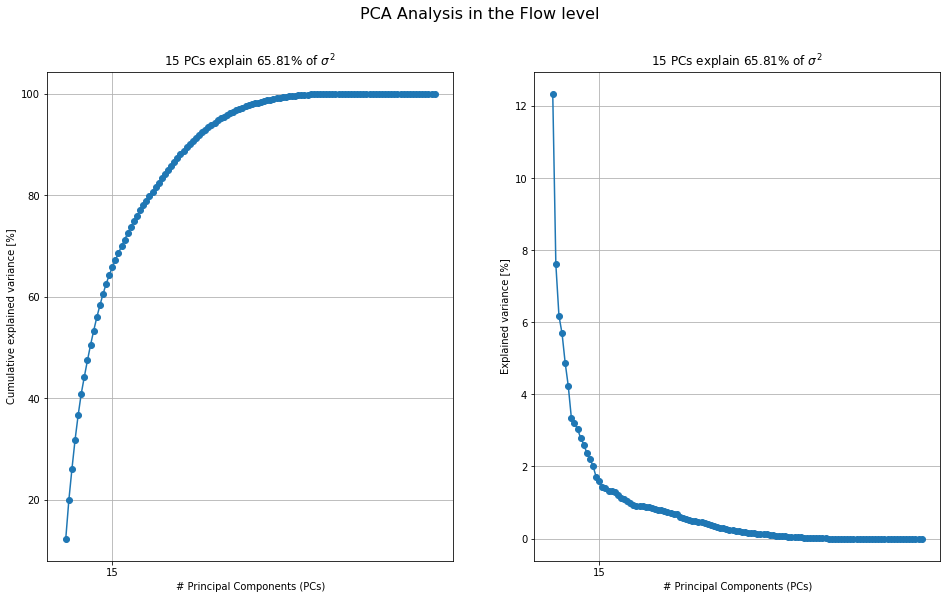

In [ ]:
# PCA must be initialized with a random state to initialize the space
pca = PCA(random_state=15)

# Fit on non-missing data
pca.fit(df_trainC.dropna())

# Variance info
explained_variance = pca.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance)
perc_cumul_exp_var = cumul_exp_var * 100

pcs = 15  # component to highlight

# Plot cumulative explained variance and per-component variance
fig, ax = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle('PCA Analysis in the Flow level', fontsize=16)

ax[0].plot(perc_cumul_exp_var, marker='o')
ax[0].set_xlabel('# Principal Components (PCs)')
ax[0].set_ylabel('Cumulative explained variance [%]')
ax[0].grid()
ax[0].set_xticks([pcs])
ax[0].set_xticklabels([pcs])
ax[0].set_title(f'{pcs} PCs explain {round(perc_cumul_exp_var[pcs], 2)}% of $\sigma^2$')

ax[1].plot(explained_variance * 100, marker='o')
ax[1].set_xlabel('# Principal Components (PCs)')
ax[1].set_ylabel('Explained variance [%]')
ax[1].grid()
ax[1].set_title(f'{pcs} PCs explain {round(perc_cumul_exp_var[pcs], 2)}% of $\sigma^2$')
ax[1].set_xticks([pcs])
ax[1].set_xticklabels([pcs])

plt.show()


##### T-SNE

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.008s...
[t-SNE] Computed neighbors for 5000 samples in 0.436s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.618850
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.008553


No handles with labels found to put in legend.


[t-SNE] KL divergence after 1000 iterations: 0.670561


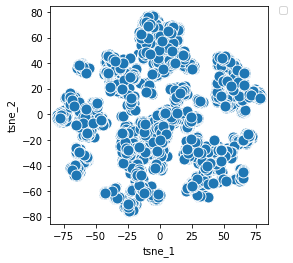

In [ ]:
from sklearn.manifold import TSNE

 
# We want to get TSNE embedding with 2 dimensions
# initialize the PCA with the best number of components, in this case, it's 3
pca = PCA(n_components=pcs, random_state=15)

# fit the data to new space
pca.fit(df_trainC.dropna())

# transform the original data into PCA components
pca_result = pca.transform(df_trainC.dropna())

# create the new dataset
df_train_pca = pd.DataFrame(pca_result, columns=[f'components {i+1}' for i in range(pcs)])

n_components = 2
tsne = TSNE(n_components, verbose=1)
df_train_pca_sampled = df_train_pca.dropna().sample(int(5e3), random_state=15)
tsne_result = tsne.fit_transform(df_train_pca_sampled)
# Two dimensions for each of our images
 
# Plot the result of our TSNE with the label color coded
# A lot of the stuff here is about making the plot look pretty and not TSNE
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1]})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

#### Domain Level

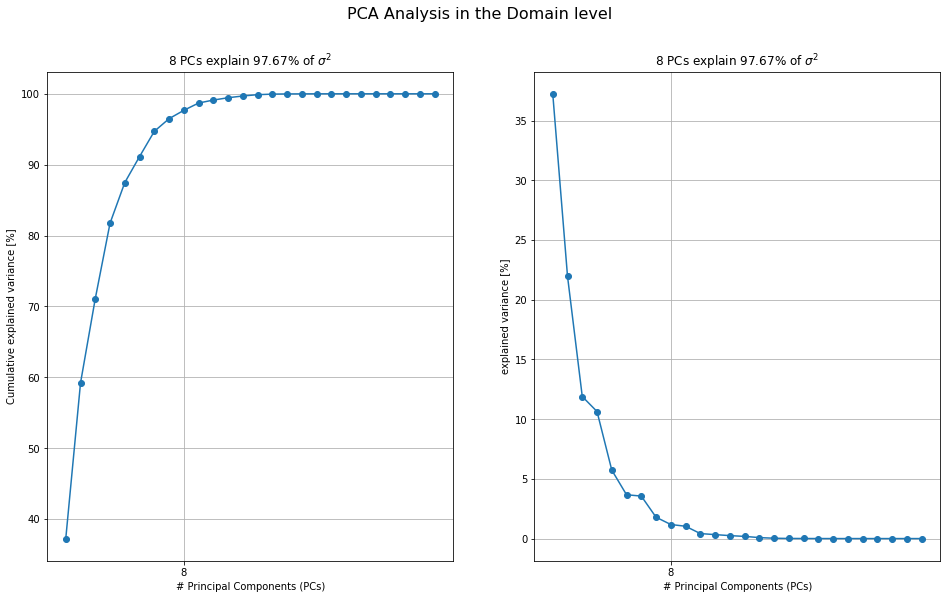

In [ ]:
# PCA must be initialized with a random state to initialize the space
pca = PCA(random_state=15)

# Fit on non-missing data
pca.fit(df_domC.dropna())

# Variance info
explained_variance = pca.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance)
perc_cumul_exp_var = cumul_exp_var * 100

pcs = 8  # component to highlight

# Plot cumulative explained variance and per-component variance
fig, ax = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle('PCA Analysis in the Domain level', fontsize=16)

ax[0].plot(perc_cumul_exp_var, marker='o')
ax[0].set_xlabel('# Principal Components (PCs)')
ax[0].set_ylabel('Cumulative explained variance [%]')
ax[0].grid()
ax[0].set_xticks([pcs])
ax[0].set_xticklabels([pcs])
ax[0].set_title(f'{pcs} PCs explain {round(perc_cumul_exp_var[pcs], 2)}% of $\sigma^2$')

ax[1].plot(explained_variance * 100, marker='o')
ax[1].set_xlabel('# Principal Components (PCs)')
ax[1].set_ylabel('explained variance [%]')
ax[1].grid()
ax[1].set_title(f'{pcs} PCs explain {round(perc_cumul_exp_var[pcs], 2)}% of $\sigma^2$')
ax[1].set_xticks([pcs])
ax[1].set_xticklabels([pcs])

plt.show()


##### T-SNE

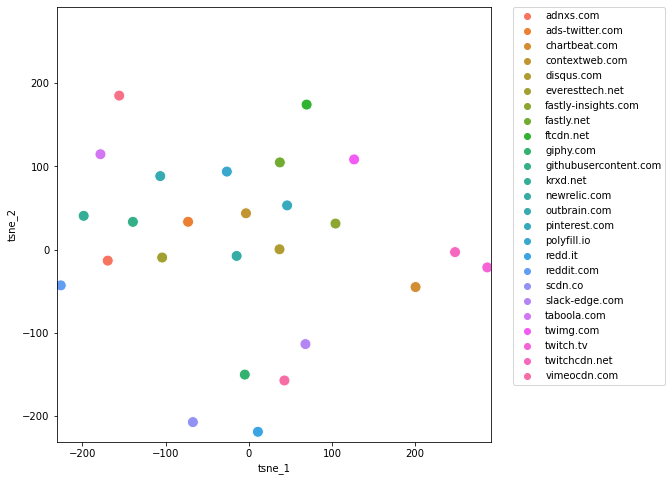

In [ ]:
from sklearn.manifold import TSNE

 
# We want to get TSNE embedding with 2 dimensions
n_components = 2
tsne = TSNE(n_components, perplexity=10)
tsne_result = tsne.fit_transform(df_domC.dropna())
# Two dimensions for each of our images
 
# Plot the result of our TSNE with the label color coded
# A lot of the stuff here is about making the plot look pretty and not TSNE
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': df_domC.index})
fig, ax = plt.subplots(1, figsize=(10, 8))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

#### Ip level


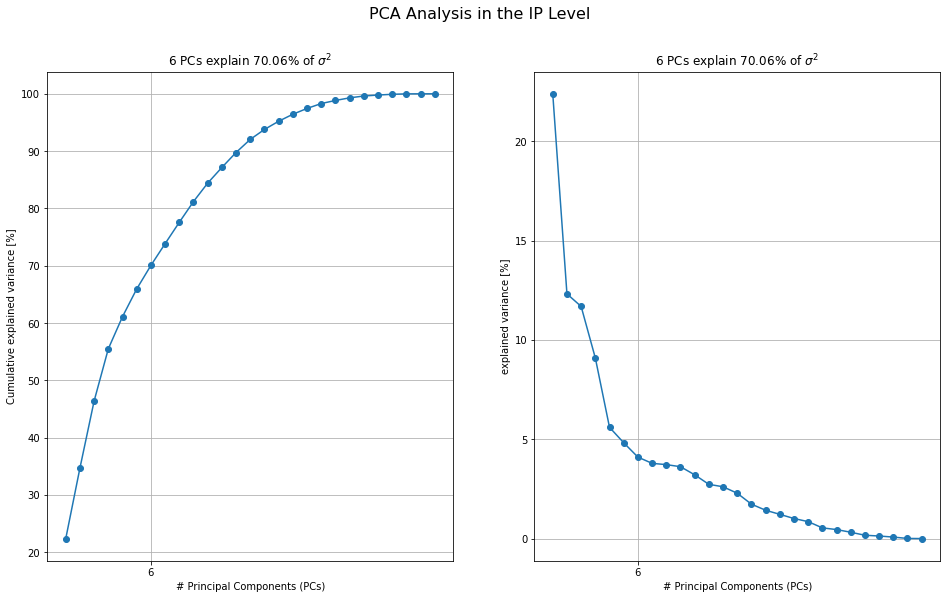

In [ ]:
# PCA must be initialized with a random state to initialize the space
pca = PCA(random_state=15)

# Fit on non-missing data
pca.fit(df_ipC.dropna())

# Variance info
explained_variance = pca.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance)
perc_cumul_exp_var = cumul_exp_var * 100

pcs = 6  # component to highlight

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle('PCA Analysis in the IP Level', fontsize=16)

ax[0].plot(perc_cumul_exp_var, marker='o')
ax[0].set_xlabel('# Principal Components (PCs)')
ax[0].set_ylabel('Cumulative explained variance [%]')
ax[0].grid()
ax[0].set_xticks([pcs])
ax[0].set_xticklabels([pcs])
ax[0].set_title(f'{pcs} PCs explain {round(perc_cumul_exp_var[pcs], 2)}% of $\sigma^2$')

ax[1].plot(explained_variance * 100, marker='o')
ax[1].set_xlabel('# Principal Components (PCs)')
ax[1].set_ylabel('explained variance [%]')
ax[1].grid()
ax[1].set_title(f'{pcs} PCs explain {round(perc_cumul_exp_var[pcs], 2)}% of $\sigma^2$')
ax[1].set_xticks([pcs])
ax[1].set_xticklabels([pcs])

plt.show()


##### T-SNE

No handles with labels found to put in legend.


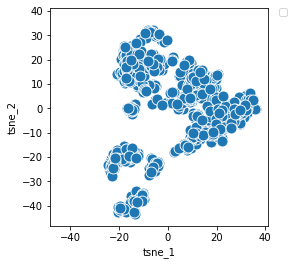

In [ ]:
from sklearn.manifold import TSNE

 
# We want to get TSNE embedding with 2 dimensions
n_components = 2
tsne = TSNE(n_components)
tsne_result = tsne.fit_transform(df_ipC.dropna())
# Two dimensions for each of our images
 
# Plot the result of our TSNE with the label color coded

tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': df_ipC.index})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

# Section 2
In this section you will develop a supervised machine learning method that classifies the
flows to predict the domain names visited by clients with high accuracy, using attributes
derived from network traffic characteristics.

Section 2.1 :   
Choose at least 3 ML methods, and perform the model training, with default
parameter configuration, evaluating the performance on both training and test set.
Output the confusion matrix, and F-measure for each class. Do you observe
overfitting or under-fitting?

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


df_train_full = pd.read_csv('/Users/martaabate/Desktop/MAGISTRALE/Machine Learning/Project/https_training.csv')
df_test_full = pd.read_csv('/Users/martaabate/Desktop/MAGISTRALE/Machine Learning/Project/https_test.csv')

# just to check if data is loaded
if 'df_train_full' not in locals() or 'df_test_full' not in locals():
    raise NameError("Error: Datasets are not defined. Please check file paths.")

# ''layered'' sampling (it is faster, since we have big dataset)
sample_size = min(50000, len(df_train_full)) 
df_train_sample, _ = train_test_split(df_train_full, train_size=sample_size,
                                stratify=df_train_full['label'], random_state=15)

# let's now use the full test set (or we can sample it if it's too slow)
df_test_sample = df_test_full 

# Features/Label - Training
X_train_raw = df_train_sample.drop(columns=['label'])
y_train = df_train_sample['label']

# Features/Label - Test
X_test_raw = df_test_sample.drop(columns=['label'])
y_test = df_test_sample['label']

# NaN
# We identify numeric columns from training data
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns

# Fill NaN with 0 for both sets using the same columns
X_train_num = X_train_raw[num_cols].fillna(0)
X_test_num = X_test_raw[num_cols].fillna(0)

# Scaling 
scaler = StandardScaler() #in this way the numbers have all the same scale -> so as not to confuse the model
# Fit on Training, Transform on Test
X_train = scaler.fit_transform(X_train_num)
X_test = scaler.transform(X_test_num)

print("Training models...") 

# kNN 
kNN = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
kNN.fit(X_train, y_train)

# Logistic Regression
# We only increase max_iter to ensure convergence
LR = LogisticRegression(max_iter=2000, n_jobs=-1) 
LR.fit(X_train, y_train)

# Random Forest
RF = RandomForestClassifier(random_state=15, n_jobs=-1)
RF.fit(X_train, y_train)


#############
# Let's define this function (for Evaluation) that gives us the reports and the confusion matrices:

def print_evaluation(model_name, y_true, y_pred, set_name):
    # Support function to print reports neatly
    print(f"\n{'-'*6} {model_name} - {set_name} SET {'-'*6}")
    print(classification_report(y_true, y_pred)) #F-measure
    print(f"Confusion Matrix ({set_name}):")
    print(confusion_matrix(y_true, y_pred))

# First: Evaluation kNN (subsample -> faster)
# we take a random subsets of 2000 points (to avoid long waiting)
k_subset = 2000 
# For Test evaluation with kNN, we also take a subset because kNN is slow on prediction
idx_test = np.random.choice(len(X_test), min(k_subset, len(X_test)), replace=False)
idx_train = np.random.choice(len(X_train), min(k_subset, len(X_train)), replace=False)

print("\nEvaluation kNN (on the subset, for higher speed)...")
# Train
y_train_pred_kNN = kNN.predict(X_train[idx_train])
print_evaluation("kNN", y_train.iloc[idx_train], y_train_pred_kNN, "TRAINING")
# Test (Using the subset of the external test file)
y_test_pred_kNN = kNN.predict(X_test[idx_test])
print_evaluation("kNN", y_test.iloc[idx_test], y_test_pred_kNN, "TEST FILE")


# Second: Logistic Regression
print("\nEvaluation: Logistic Regression...")
# Train
y_train_pred_LR = LR.predict(X_train)
print_evaluation("Logistic Regression", y_train, y_train_pred_LR, "TRAINING")
# Test
y_test_pred_LR = LR.predict(X_test)
print_evaluation("Logistic Regression", y_test, y_test_pred_LR, "TEST FILE")


# Third)  Random Forest
print("\nEvaluation: Random Forest...")
# Train
y_train_pred_RF = RF.predict(X_train)
print_evaluation("Random Forest", y_train, y_train_pred_RF, "TRAINING")
# Test
y_test_pred_RF = RF.predict(X_test)
print_evaluation("Random Forest", y_test, y_test_pred_RF, "TEST FILE")

Training models...

Evaluation kNN (on the subset, for higher speed)...

------ kNN - TRAINING SET ------
                       precision    recall  f1-score   support

               _other       0.70      0.84      0.76       487
            adnxs.com       0.83      0.64      0.72        47
      ads-twitter.com       0.55      0.46      0.50        13
        chartbeat.com       0.30      0.40      0.34        15
       contextweb.com       0.61      0.75      0.68        36
           disqus.com       0.59      0.39      0.47        41
      everesttech.net       0.62      0.54      0.58        48
  fastly-insights.com       0.85      0.85      0.85        20
           fastly.net       0.78      0.60      0.68        30
            ftcdn.net       0.94      0.98      0.96        51
            giphy.com       0.77      0.80      0.79        51
githubusercontent.com       0.72      0.72      0.72        64
             krxd.net       0.70      0.78      0.74       139
         ne

COMMENTS FOR US:   
What this part of code does: we take the data from 'https_training', we 'preprocess', we train three different models and then we check how good they are to guess the column 'label'.
Since our dataset is very big, we extract a 'smaller' piece.
If there are holes in our data, we put 0.
We use: 
    1) kNN (k-Nearest Neighbors): it looks at the 5 nearest neighbors and then chooses the one with higher votes (it's easy but a bit slow)
    2) Logistic regression: it separates the classes
    3) Random Forest: it creates a lot of ''questions'' and then it puts together the data (which appears, from our data, to be the best)

At the end we compare the predictitons with the reality (y_true vs y_pred). Also we have the confusion matrix where we see how many times we were wrong (???)

2.2:   
Tune the hyper-parameters of the models through cross-validation. How do
performance vary? Which model generates the best performance?

In [17]:
from sklearn.model_selection import GridSearchCV

# HYPER-PARAMETER TUNING (Cross-Validation)
print("Start Tuning Hyper-Parameters (This operation may take some time)...")

# let's define a function to execute the tuning and then  print the results 
def tune_and_evaluate(model, param_grid, name, X_train, y_train, X_test, y_test):
    print(f"\n--- Tuning {name} ---")
    
    #let's use GridSearch for the Cross-Validation part
    # scoring='f1_weighted' -> try to maximize the medium F-measure 
    grid = GridSearchCV(model, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1) #cv=3 -> 3 cycles
    
    # Tuning. We have (again) to scale the data
    # For kNN we reduce the training data for tuning -> otherwise it takes hours (since this algorithm is slow)
    if name == "kNN":
        # we use just 5000 sample, in order to find the best paraameters for kNN 
        idx_tune = np.random.choice(len(X_train), min(5000, len(X_train)), replace=False)
        grid.fit(X_train[idx_tune], y_train.iloc[idx_tune])
    else:
        grid.fit(X_train, y_train)
    
    print(f"Best found parameters: {grid.best_params_}")
    print(f"Best Score (CV) during training: {grid.best_score_:.4f}")
    
    # Let's test this model (the best) on the tet dataset: 
    best_model = grid.best_estimator_
    
    # Now we have to train the model on the entire training set
    if name == "kNN":
        print(f"Re-training {name} with the best parameters on the entire training set: ")
        best_model.fit(X_train, y_train)
        
    print(f"{name} Tuned Evaluation on the test set:")
    y_pred_test = best_model.predict(X_test)
    
    # Report
    print(classification_report(y_test, y_pred_test))
    print(f"Confusion Matrix ({name} Tuned):")
    print(confusion_matrix(y_test, y_pred_test))
    
    return best_model

# First: Tuning kNN 
params_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'] # 'distance' dà più importanza ai vicini più stretti
}
best_kNN = tune_and_evaluate(KNeighborsClassifier(n_jobs=-1), params_knn, "kNN", X_train, y_train, X_test, y_test)

# Second: Tuning Logistic Regression 
params_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs']
}
best_LR = tune_and_evaluate(LogisticRegression(max_iter=2000, n_jobs=-1), params_lr, "Logistic Regression", X_train, y_train, X_test, y_test)

# Third: Tuning Random Forest 
params_rf = {
    'n_estimators': [50, 100], 
    'max_depth': [10, 20, None] # (None = unlimited)
}
best_RF = tune_and_evaluate(RandomForestClassifier(random_state=15, n_jobs=-1), params_rf, "Random Forest", X_train, y_train, X_test, y_test)


Start Tuning Hyper-Parameters (This operation may take some time)...

--- Tuning kNN ---
Best found parameters: {'n_neighbors': 5, 'weights': 'distance'}
Best Score (CV) during training: 0.4991
Re-training kNN with the best parameters on the entire training set: 
kNN Tuned Evaluation on the test set:
                       precision    recall  f1-score   support

               _other       0.57      0.55      0.56     34777
            adnxs.com       0.48      0.42      0.45      2942
      ads-twitter.com       0.27      0.17      0.21      1135
        chartbeat.com       0.41      0.30      0.35      1717
       contextweb.com       0.34      0.28      0.31      2383
           disqus.com       0.26      0.15      0.19      3246
      everesttech.net       0.34      0.27      0.30      2894
  fastly-insights.com       0.46      0.67      0.54       686
           fastly.net       0.16      0.13      0.14      1455
            ftcdn.net       0.89      0.88      0.88      1607
    

NOW with this code it takes ≈ 1min and 50 sec to generate all the results... too long?